In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [2]:
# Load the dataset
df = pd.read_csv("/content/banking_data.csv")

In [3]:
# Display basic information about the dataset
print("Dataset Overview:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45216 entries, 0 to 45215
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45216 non-null  int64 
 1   job             45216 non-null  object
 2   marital         45213 non-null  object
 3   marital_status  45213 non-null  object
 4   education       45213 non-null  object
 5   default         45216 non-null  object
 6   balance         45216 non-null  int64 
 7   housing         45216 non-null  object
 8   loan            45216 non-null  object
 9   contact         45216 non-null  object
 10  day             45216 non-null  int64 
 11  month           45216 non-null  object
 12  day_month       45216 non-null  object
 13  duration        45216 non-null  int64 
 14  campaign        45216 non-null  int64 
 15  pdays           45216 non-null  int64 
 16  previous        45216 non-null  int64 
 17  poutcome        45216 non-null  

In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45216.000000,45216.000000,45216.000000,45216.000000,45216.000000,45216.000000,45216.000000
mean,40.938186,1362.277844,15.806507,258.166202,2.763668,40.202428,0.580657
std,10.621249,3044.609674,8.322022,257.515482,3.097896,100.128248,2.303778
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.500000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
# Create a copy of the dataframe to avoid modifying the original one
df_numeric = df.copy()

# Convert categorical variables into numerical representations
# Encode categorical variables
label_encoders = {}
for column in df_numeric.select_dtypes(include=['object']).columns:
  label_encoders[column] = LabelEncoder()
  df_numeric[column] = label_encoders[column].fit_transform(df_numeric[column])

In [9]:
# Convert target variable ('y') into binary (0 = No, 1 = Yes)
df['y'] = df['y'].map({'no': 0, 'yes': 1})

In [10]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age               0
job               0
marital           3
marital_status    3
education         3
default           0
balance           0
housing           0
loan              0
contact           0
day               0
month             0
day_month         0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
y                 0
dtype: int64


In [11]:
# Drop rows where 'marital_status' is missing
df = df.dropna(subset=['marital_status'])

# Confirm the missing values are dropped
print("\nMissing Values after dropping 'marital_status' nulls:")
print(df.isnull().sum())


Missing Values after dropping 'marital_status' nulls:
age               0
job               0
marital           0
marital_status    0
education         3
default           0
balance           0
housing           0
loan              0
contact           0
day               0
month             0
day_month         0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
y                 0
dtype: int64


# Answering the questions

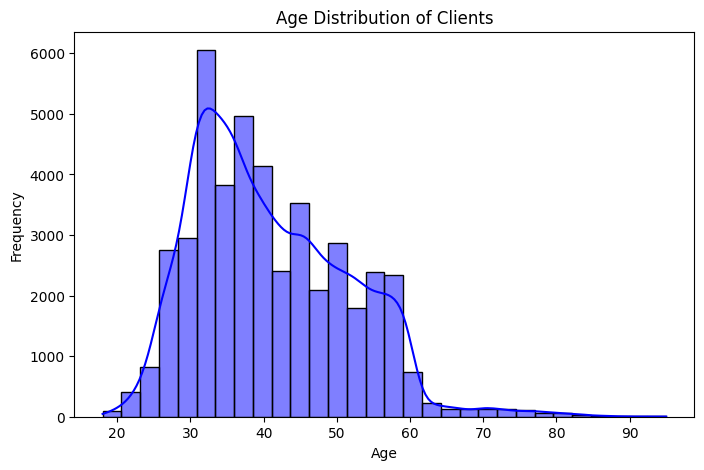

In [12]:
# 1. What is the distribution of age among the clients?
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title("Age Distribution of Clients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

<ipython-input-35-6913ee3401bc>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['job'], order=df['job'].value_counts().index, palette="viridis")


<Figure size 1400x600 with 0 Axes>

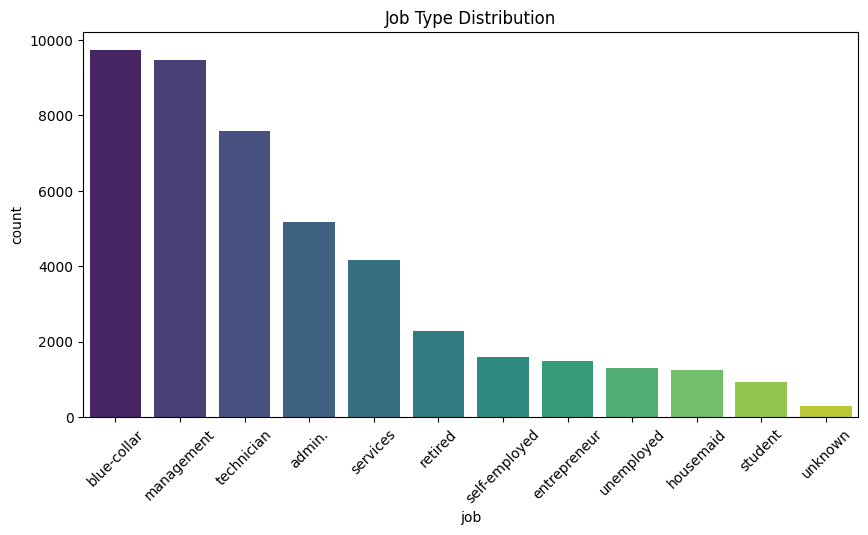

In [35]:
# 2. How does the job type vary among the clients?
plt.figure(figsize=(14, 6))
plt.figure(figsize=(10, 5))
sns.countplot(x=df['job'], order=df['job'].value_counts().index, palette="viridis")
plt.title("Job Type Distribution")
plt.xticks(rotation=45)
plt.show()

<ipython-input-14-dbc1cc1a7f5a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['marital'], order=df['marital'].value_counts().index, palette="coolwarm")


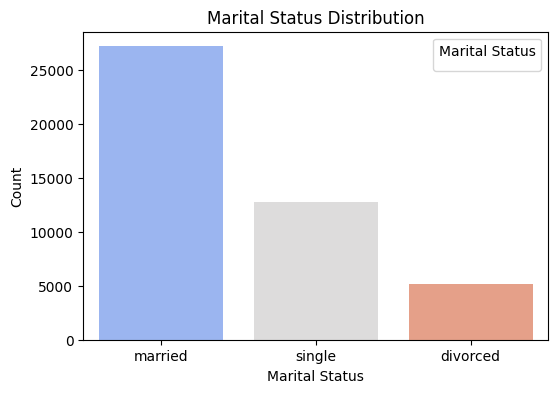

In [14]:
# 3. What is the marital status distribution of the clients?
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=df['marital'], order=df['marital'].value_counts().index, palette="coolwarm")

# Add legend manually
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, df['marital'].unique(), title="Marital Status")

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

<ipython-input-34-0d241824df67>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['education'], order=df['education'].value_counts().index, palette="magma")


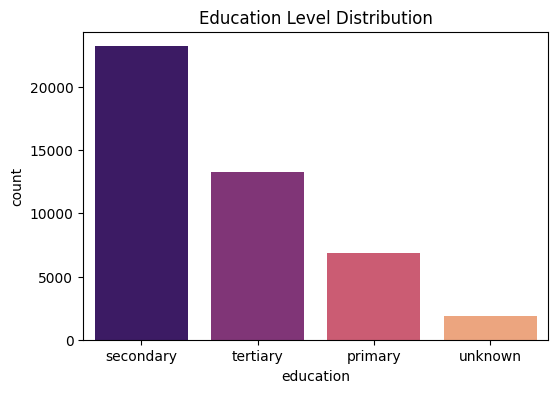

In [34]:
# 4. What is the level of education among the clients?
plt.figure(figsize=(6, 4))
sns.countplot(x=df['education'], order=df['education'].value_counts().index, palette="magma")
plt.title("Education Level Distribution")
plt.show()


Proportion of Clients with Credit in Default:
default
no     98.197421
yes     1.802579
Name: proportion, dtype: float64


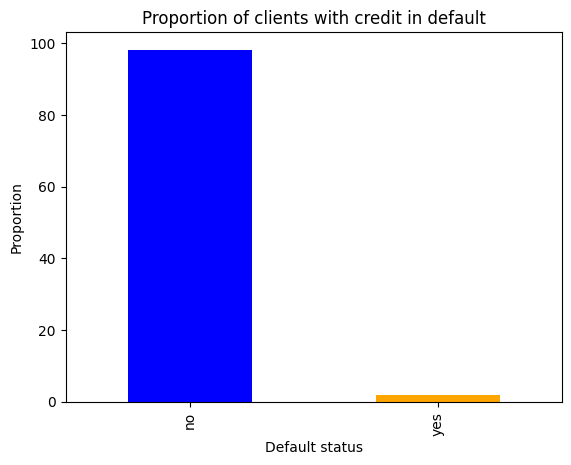

In [36]:
# 5. What proportion of clients have credit in default?
default_counts = df['default'].value_counts(normalize=True) * 100
print("\nProportion of Clients with Credit in Default:")
print(default_counts)

#Credit Default Proportion
default_counts.plot(kind='bar', color=['blue','orange'])
plt.title("Proportion of clients with credit in default")
plt.xlabel("Default status")
plt.ylabel("Proportion")
plt.show()

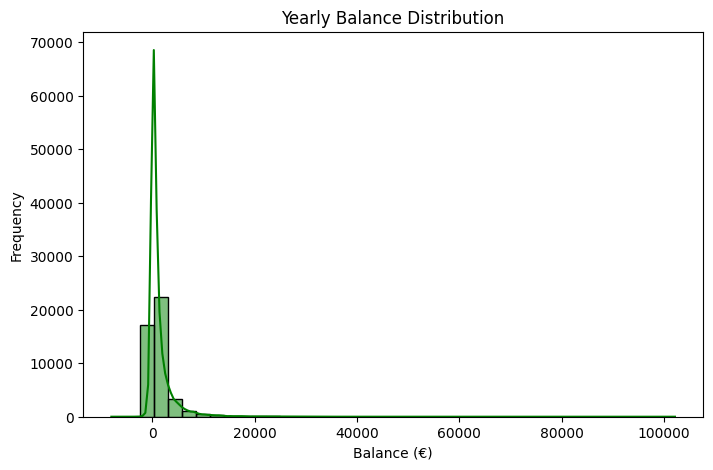

In [17]:
# 6. What is the distribution of average yearly balance among the clients?
plt.figure(figsize=(8, 5))
sns.histplot(df['balance'], bins=40, kde=True, color='green')
plt.title("Yearly Balance Distribution")
plt.xlabel("Balance (€)")
plt.ylabel("Frequency")
plt.show()


Number of Clients with Housing Loans:
housing
yes    25130
no     20083
Name: count, dtype: int64


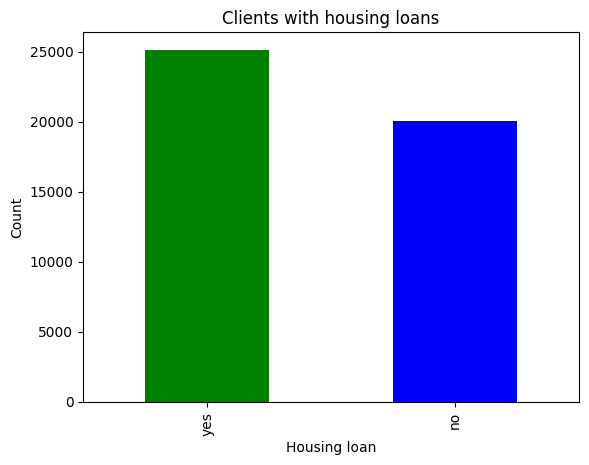

In [38]:
# 7. How many clients have housing loans?
housing_counts = df['housing'].value_counts()
print("\nNumber of Clients with Housing Loans:")
print(housing_counts)

housing_counts.plot(kind='bar', color=['green','blue'])
plt.title("Clients with housing loans")
plt.xlabel("Housing loan")
plt.ylabel("Count")
plt.show()


Number of Clients with Personal Loans:
loan
no     37969
yes     7244
Name: count, dtype: int64


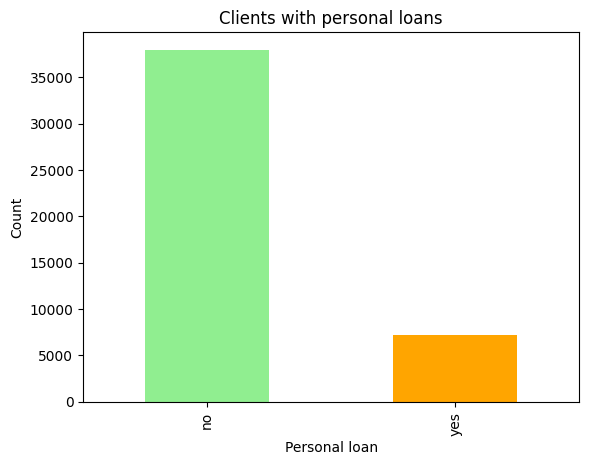

In [40]:
# 8. How many clients have personal loans?
loan_counts = df['loan'].value_counts()
print("\nNumber of Clients with Personal Loans:")
print(loan_counts)

loan_counts.plot(kind='bar', color=['lightgreen','orange'])
plt.title("Clients with personal loans")
plt.xlabel("Personal loan")
plt.ylabel("Count")
plt.show()

<ipython-input-41-29f92550c576>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['contact'], order=df['contact'].value_counts().index, palette="pastel")


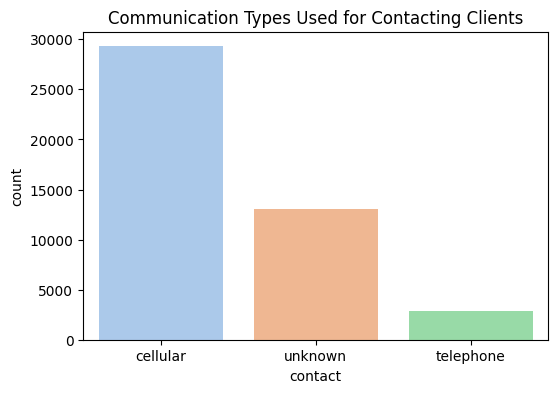

In [41]:
# 9. What are the communication types used for contacting clients during the campaign?
plt.figure(figsize=(6, 4))
sns.countplot(x=df['contact'], order=df['contact'].value_counts().index, palette="pastel")
plt.title("Communication Types Used for Contacting Clients")
plt.show()

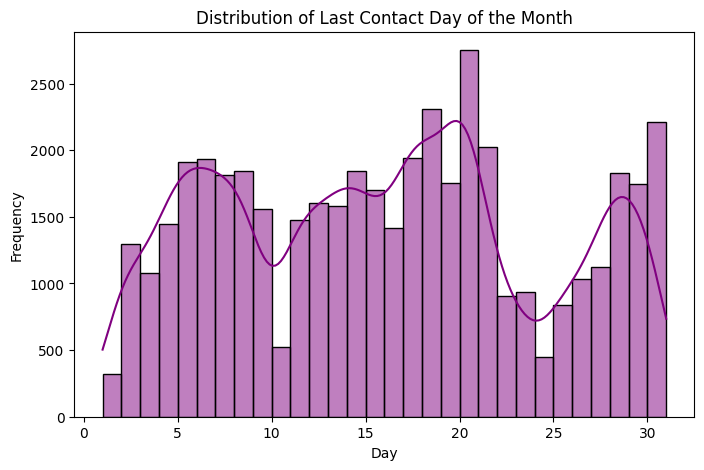

In [21]:
# 10. What is the distribution of the last contact day of the month?
plt.figure(figsize=(8, 5))
sns.histplot(df['day'], bins=30, kde=True, color='purple')
plt.title("Distribution of Last Contact Day of the Month")
plt.xlabel("Day")
plt.ylabel("Frequency")
plt.show()

<ipython-input-46-3760de3d048e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['month'], order=["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"],  palette="coolwarm")


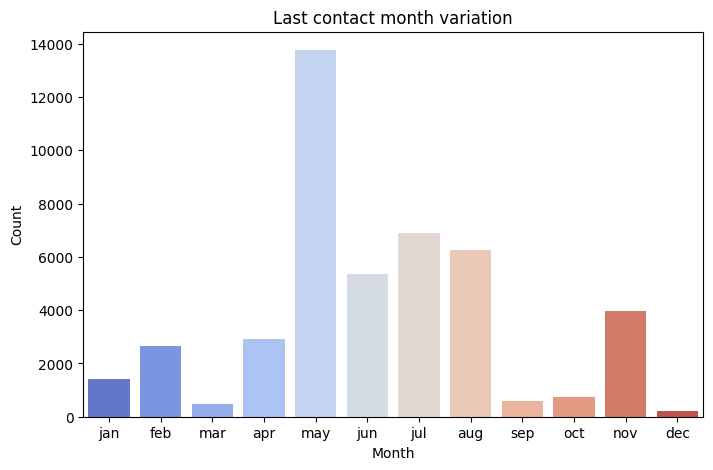

In [46]:
# 11. How does the last contact month vary among the clients?
plt.figure(figsize=(8, 5))
sns.countplot(x=df['month'], order=["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"],  palette="coolwarm")
plt.title("Last contact month variation")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

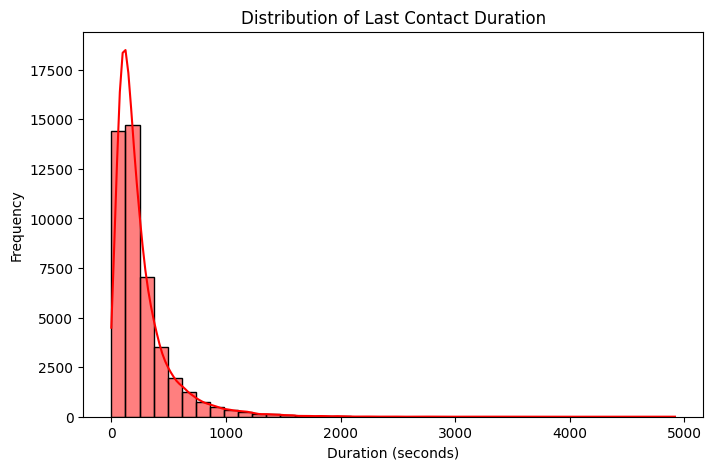

In [23]:
# 12. What is the distribution of the duration of the last contact?
plt.figure(figsize=(8, 5))
sns.histplot(df['duration'], bins=40, kde=True, color='red')
plt.title("Distribution of Last Contact Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

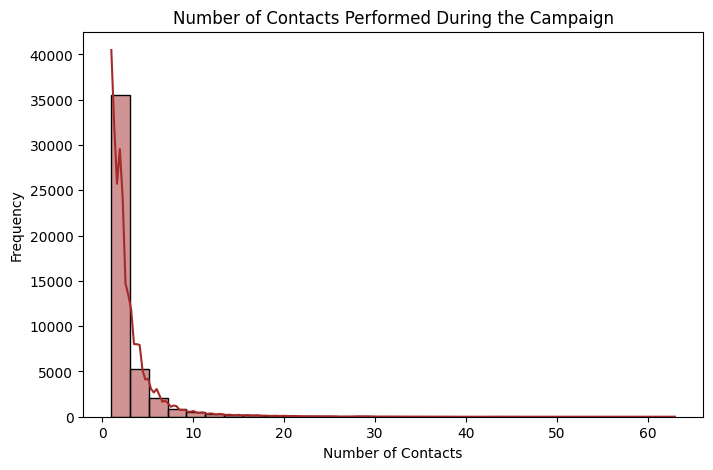

In [24]:
# 13. How many contacts were performed during the campaign for each client?
plt.figure(figsize=(8, 5))
sns.histplot(df['campaign'], bins=30, kde=True, color='brown')
plt.title("Number of Contacts Performed During the Campaign")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")
plt.show()

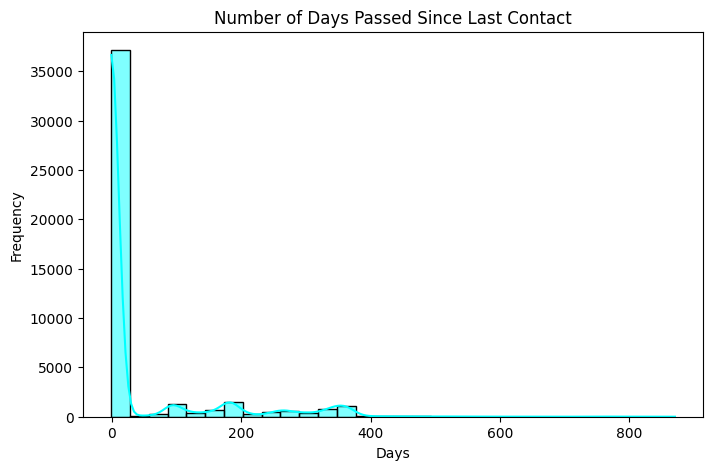

In [25]:
# 14. What is the distribution of the number of days passed since the client was last contacted from a previous campaign?
plt.figure(figsize=(8, 5))
sns.histplot(df['pdays'], bins=30, kde=True, color='cyan')
plt.title("Number of Days Passed Since Last Contact")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

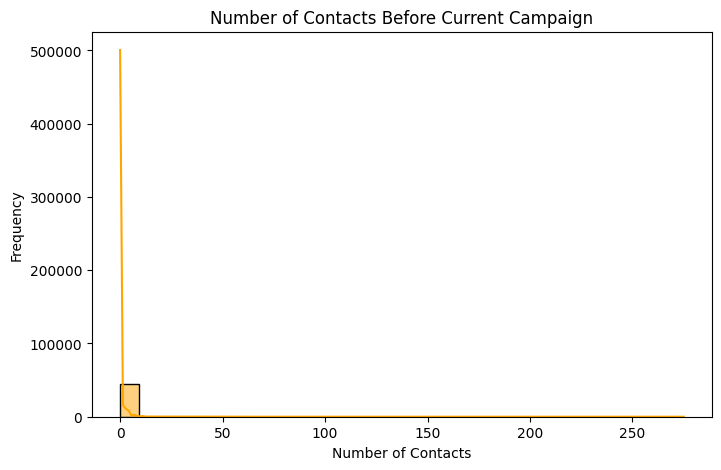

In [26]:
# 15. How many contacts were performed before the current campaign for each client?
plt.figure(figsize=(8, 5))
sns.histplot(df['previous'], bins=30, kde=True, color='orange')
plt.title("Number of Contacts Before Current Campaign")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")
plt.show()

<ipython-input-49-e3b7668bed9a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['poutcome'], palette="coolwarm")


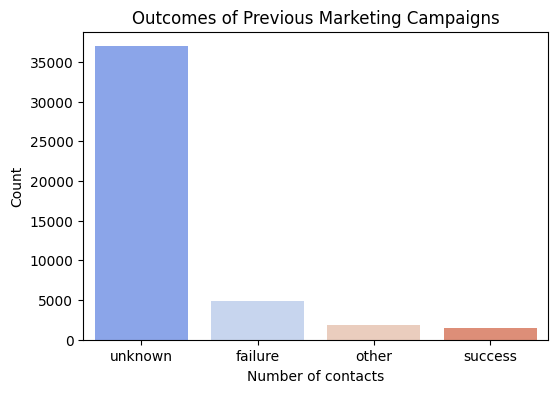

In [49]:
# 16. What were the outcomes of the previous marketing campaigns?
plt.figure(figsize=(6, 4))
sns.countplot(x=df['poutcome'], palette="coolwarm")
plt.title("Outcomes of Previous Marketing Campaigns")
plt.xlabel("Number of contacts")
plt.ylabel("Count")
plt.show()

<ipython-input-51-26ae750b97b0>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['y'], order=df['y'].value_counts().index, palette="coolwarm")


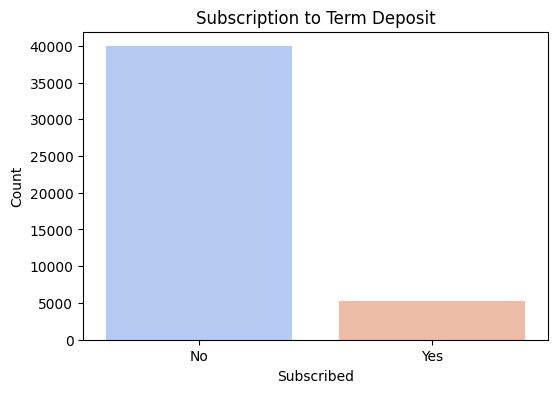

In [51]:
# 17. What is the distribution of clients who subscribed to a term deposit vs. those who did not?
plt.figure(figsize=(6, 4))
sns.countplot(x=df['y'], order=df['y'].value_counts().index, palette="coolwarm")
plt.title("Subscription to Term Deposit")
plt.xlabel("Subscribed")
plt.ylabel("Count")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

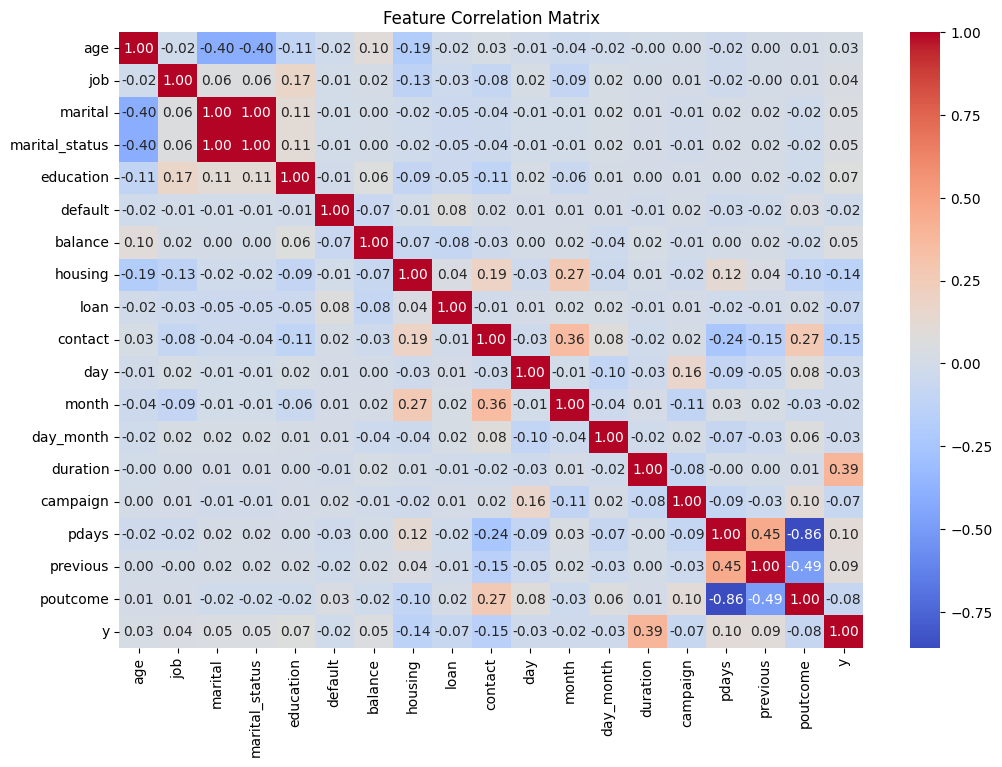

In [30]:
# 18. Are there any correlations between different attributes and the likelihood of subscribing to a term deposit?
plt.figure(figsize=(12, 8))
# Calculate correlation on the df_numeric dataframe which has categorical columns encoded
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


Model Performance:
Accuracy: 0.90
AUC-ROC Score: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7975
           1       0.63      0.42      0.50      1069

    accuracy                           0.90      9044
   macro avg       0.78      0.69      0.72      9044
weighted avg       0.89      0.90      0.89      9044



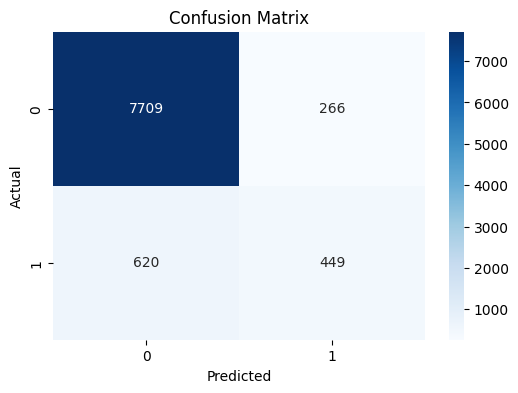

In [32]:
# Predictive Modeling
# Use the df_numeric dataframe which has categorical columns encoded
X = df_numeric.drop(columns=['y'])  # Features
y = df_numeric['y']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nModel Performance:")
print(f"Accuracy: {accuracy:.2f}")
print(f"AUC-ROC Score: {roc_auc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()